In [ ]:
# How do wildfire intensity, physical size, and event duration vary across Africa during the past five days, 
    #and what spatial patterns emerge from these differences?

In [38]:
import requests
import pandas as pd
import time

#import 
# Range parameter: 5 = last 5 days of detections, before 1
url_api = "https://firms.modaps.eosdis.nasa.gov/api/area/csv/dc38faa964bb2d75d020b913a3579aa3/VIIRS_SNPP_NRT/world/5"

response = requests.get(url_api)
print(response.status_code)
print(response.text[:200]) 

fires_df = pd.read_csv(url_api)
fires_df.info()
fires_df.head()



200
latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
68.64421,57.96012,328.76,0.57,0.52,2026-05-03,54,N,VIIRS,n,2.0NRT,268.08,2.46
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134253 entries, 0 to 134252
Data columns (total 14 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   latitude    134253 non-null  float64
 1   longitude   134253 non-null  float64
 2   bright_ti4  134253 non-null  float64
 3   scan        134253 non-null  float64
 4   track       134253 non-null  float64
 5   acq_date    134253 non-null  object 
 6   acq_time    134253 non-null  int64  
 7   satellite   134253 non-null  object 
 8   instrument  134253 non-null  object 
 9   confidence  134253 non-null  object 
 10  version     134253 non-null  object 
 11  bright_ti5  134253 non-null  float64
 12  frp         134253 non-null  float64
 13  daynight    134253 non-null  object 
dtypes: floa

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,68.64421,57.96012,328.76,0.57,0.52,2026-05-03,54,N,VIIRS,n,2.0NRT,268.08,2.46,D
1,68.64610,57.95589,327.43,0.57,0.52,2026-05-03,54,N,VIIRS,n,2.0NRT,268.25,3.85,D
2,58.21041,30.87205,305.40,0.52,0.41,2026-05-03,58,N,VIIRS,n,2.0NRT,277.90,0.97,N
3,58.21090,30.87533,304.22,0.52,0.41,2026-05-03,58,N,VIIRS,n,2.0NRT,278.08,1.02,N
4,58.70131,30.11929,317.81,0.48,0.40,2026-05-03,58,N,VIIRS,n,2.0NRT,276.30,2.85,N


In [40]:
##inspect and clean the data

# Check for missing values
fires_df.isnull().sum()

# Check confidence levels
fires_df['confidence'].value_counts()

confidence
n    115259
l     13801
h      5193
Name: count, dtype: int64

In [69]:
## convert coordinate into geometry
import geopandas as gpd

fires_gdf = gpd.GeoDataFrame(
    fires_df,
    geometry=gpd.points_from_xy(fires_df['longitude'], fires_df['latitude']),
    crs='EPSG:4326')

## load world and subset just africa
import os
os.getcwd() #prints current working directory
os.listdir("../data") # ... = go up one folder
os.listdir("../data/ne_110m_admin_0_countries")

world = gpd.read_file("../data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
africa = world[world["CONTINENT"] == "Africa"]

fires_africa = gpd.sjoin(
    fires_gdf,
    africa[["geometry", "NAME"]],
    how="inner",
    predicate="within")




In [70]:
fires_africa.head()
fires_africa.info()
fires_africa['NAME'].value_counts().head(10)
#how many fires per country
#whether geometry is correct
#whether the join added the NAME column

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 41417 entries, 255 to 134252
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   latitude     41417 non-null  float64 
 1   longitude    41417 non-null  float64 
 2   bright_ti4   41417 non-null  float64 
 3   scan         41417 non-null  float64 
 4   track        41417 non-null  float64 
 5   acq_date     41417 non-null  object  
 6   acq_time     41417 non-null  int64   
 7   satellite    41417 non-null  object  
 8   instrument   41417 non-null  object  
 9   confidence   41417 non-null  object  
 10  version      41417 non-null  object  
 11  bright_ti5   41417 non-null  float64 
 12  frp          41417 non-null  float64 
 13  daynight     41417 non-null  object  
 14  geometry     41417 non-null  geometry
 15  index_right  41417 non-null  int64   
 16  NAME         41417 non-null  object  
dtypes: float64(7), geometry(1), int64(2), object(7)
memory usage: 5

NAME
Dem. Rep. Congo    14175
Madagascar          5992
Guinea              3026
S. Sudan            2873
Ethiopia            1356
Algeria             1175
Sudan               1114
Angola              1055
Nigeria              982
Libya                903
Name: count, dtype: int64

In [72]:
##Convert date + time into a proper datetime
fires_africa['acq_time'] = fires_africa['acq_time'].astype(str).str.zfill(4) #zfill: HHMM->"0930", "0054"


fires_africa['datetime'] = pd.to_datetime(
    fires_africa['acq_date'] + ' ' + #' ' = space -> besseren überblick
    fires_africa['acq_time'].str[:2] + ':' + #hours divided after by :
    fires_africa['acq_time'].str[2:],# minutes
    format='%Y-%m-%d %H:%M')


In [77]:
##FRP = Fire Radiative Power → main intensity metric
fires_africa['frp'].describe()

#shows intensity by country in africa
fires_africa.groupby('NAME')['frp'].mean().sort_values(ascending=False) #from highest to slowest int.





NAME
eSwatini                31.734412
Guinea                  23.717092
Eritrea                 21.034167
Guinea-Bissau           13.889502
Liberia                 11.754187
Sierra Leone            11.537194
Sudan                   10.618330
Chad                    10.596099
Mali                    10.203984
S. Sudan                 9.825628
Ethiopia                 8.978673
Cameroon                 8.137876
Congo                    7.746821
Senegal                  7.642973
Niger                    7.569437
Zambia                   7.396788
Egypt                    7.365858
Dem. Rep. Congo          7.298836
Gambia                   6.983738
Zimbabwe                 6.854114
Central African Rep.     6.497767
Côte d'Ivoire            6.343375
Nigeria                  6.264949
Madagascar               6.113630
Ghana                    5.943358
Angola                   5.725621
Togo                     5.722222
Uganda                   5.266250
South Africa             5.242532
Kenya    

In [80]:
# int. group by date
fires_africa['date'] = fires_africa['datetime'].dt.date
fires_africa.groupby('date')['frp'].mean()


date
2026-05-03    8.376177
2026-05-04    9.065230
2026-05-05    8.110385
2026-05-06    9.340919
2026-05-07    6.890346
Name: frp, dtype: float64

In [81]:
##fire size : pixel area
fires_africa['pixel_area_km2'] = fires_africa['scan'] * fires_africa['track'] #in km^2
#scan pixel briete km und track pixel länge km
fires_africa['pixel_area_km2'].describe() #zeigt zusammenfassung der pixel grössen


count    41417.000000
mean         0.214043
std          0.082375
min          0.136800
25%          0.159600
50%          0.192000
75%          0.236500
max          0.624000
Name: pixel_area_km2, dtype: float64

In [89]:
## estimation of fire duration
#group occur in the same location over time

fires_africa['lat_bin'] = fires_africa['latitude'].round(1)
fires_africa['lon_bin'] = fires_africa['longitude'].round(1)
    #2 Punkte: 0.01° auseinander liegen, gehören trz zum gleichen Feuer-> runden dezimalstelle 
        # so spatial clusters-> represent fire locations

duration_stats = fires_africa.groupby(['lat_bin','lon_bin'])['datetime'].agg(['min','max','count'])
    #group fire with same roundet lat and lon-> al points the on same location auftreten
    # min: time when fire first seen
    #max: time when fire last seen,   count: number of time satellites saw fire


duration_stats['duration_hours'] = (duration_stats['max'] - duration_stats['min']).dt.total_seconds() / 3600
#to count whole duration need .total_seconds(), time delta works with seconds there are no hours or minute
# after count of seconds / bei 3600 to get hours




In [91]:
## dauer nach land vergleichen
fires_with_duration = fires_africa.merge(
    duration_stats['duration_hours'],
    left_on=['lat_bin','lon_bin'],
    right_index=True)
fires_with_duration.groupby('NAME')['duration_hours'].mean().sort_values(ascending=False)



NAME
Libya                   90.842027
Algeria                 73.209716
Madagascar              59.894860
Egypt                   49.376294
S. Sudan                41.676082
Guinea-Bissau           38.850277
Zimbabwe                37.917267
Guinea                  36.571739
Tunisia                 34.047917
Ethiopia                30.774607
Dem. Rep. Congo         28.550481
South Africa            28.534415
Gabon                   27.111158
Nigeria                 26.137101
Cameroon                22.978584
Gambia                  21.670249
Tanzania                21.394809
Senegal                 19.934610
Sierra Leone            17.406799
Mali                    17.298730
Eritrea                 17.255556
Congo                   17.187442
Liberia                 16.877778
Zambia                  16.228021
Niger                   15.353404
Ghana                   15.298284
Sudan                   14.739078
Chad                    13.354885
Mozambique              13.271987
Angola   

<Axes: xlabel='duration_hours', ylabel='frp'>

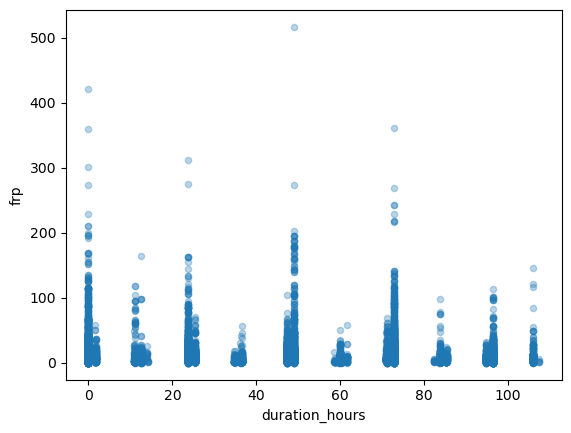

In [95]:
## dauer vs intensität
fires_with_duration.plot.scatter(
    x='duration_hours',
    y='frp',
    alpha=0.3)



<Axes: xlabel='duration_hours', ylabel='pixel_area_km2'>

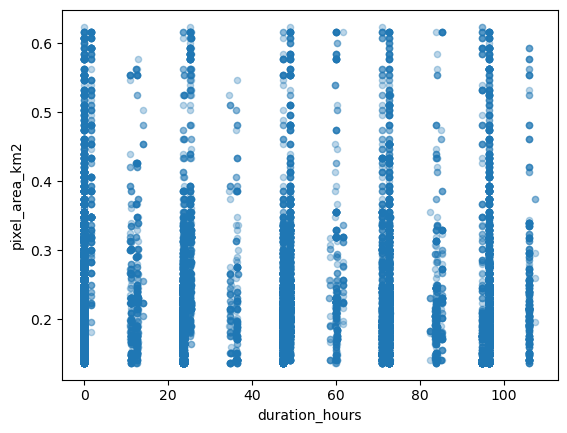

In [97]:
## dauer vs fire size
fires_with_duration.plot.scatter(
    x='duration_hours',
    y='pixel_area_km2',
    alpha=0.3)


In [98]:
## duration back into the fire dataset -> capable to see on map
fires_with_duration = fires_africa.merge(
    duration_stats['duration_hours'],
    left_on=['lat_bin','lon_bin'],
    right_index=True)
# fires have: FRP, size, duration 



In [100]:
#map
import folium

m = folium.Map(location=[0, 20], zoom_start=3)
#Startpunkt: Afrika zentrum